In [2]:
import numpy as np
import os
import mat73
import seaborn as sb
import pingouin as pg
import PcmPy as pcm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import ttest_1samp
import pickle
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from pathlib import Path
import sys
from SensoriMotorPrediction.vis import plot_rdm, plot_surf
import SensoriMotorPrediction.globals as gl

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.5010671094999073, pval=0.0019530226706477509
PMd: tval=4.598273847949548, pval=0.00024963097770992716
PMv: tval=5.3808301566361045, pval=6.25938114432965e-05
M1: tval=4.899815837755327, pval=0.00014509603765901948
S1: tval=7.019441292795594, pval=4.537072556005718e-06
SPLa: tval=4.418617091916282, pval=0.000346742520476346
SPLp: tval=6.069299768949967, pval=1.986392417741581e-05


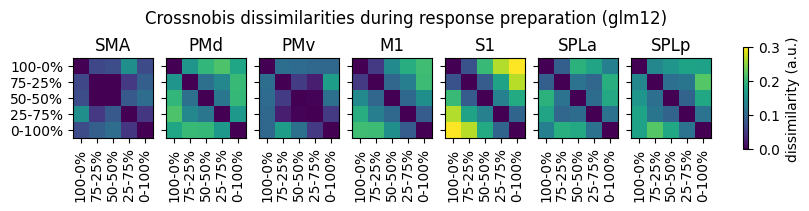

In [3]:
experiment = 'smp2'
H = 'L'
epoch = 'plan'
rois = gl.rois['ROI']
glm = 12

vmin, vmax = 0, .3

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=2.0374470119549692, pval=0.031247091561656316
PMd: tval=5.07348826605635, pval=0.00010672392702651416
PMv: tval=4.278449666984642, pval=0.0004492312478857293
M1: tval=6.573832342341147, pval=8.931440314497287e-06
S1: tval=3.572946137369057, pval=0.0017017758724022758
SPLa: tval=3.638183030629285, pval=0.0015021904853348323
SPLp: tval=4.535448934650985, pval=0.0002799066493913817


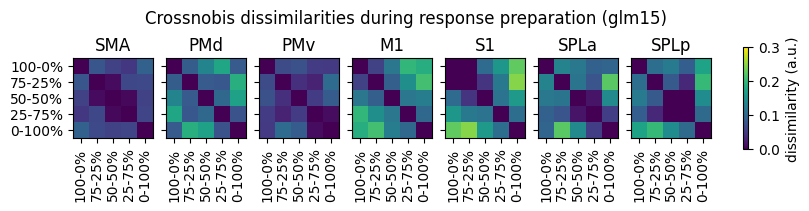

In [4]:
glm = 15
fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_rdm(fig, axs, r, D, ['100-0%', '75-25%', '50-50%', '25-75%', '0-100%'], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle(f'Crossnobis dissimilarities during response preparation (glm{glm})')
fig.savefig(os.path.join('figures', f'crossnobis.plan.glm{glm}.pdf'))
plt.show()

,,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
roi,,,,,,,,,
M1,T-test,5.781434,13,greater,3.184139e-05,"[0.38, inf]",1.545153,854.749,0.999930
PMd,T-test,7.813096,13,greater,1.446973e-06,"[0.44, inf]",2.088138,1.33e+04,1.000000
PMv,T-test,5.489530,13,greater,5.199048e-05,"[0.33, inf]",1.467139,555.966,0.999796
S1,T-test,16.036015,13,greater,3.020026e-10,"[0.64, inf]",4.285805,2.916e+07,1.000000
SMA,T-test,5.972067,13,greater,2.326604e-05,"[0.29, inf]",1.596102,1126.564,0.999967
SPLa,T-test,5.960572,13,greater,2.370700e-05,"[0.32, inf]",1.593030,1108.083,0.999965
SPLp,T-test,7.475992,13,greater,2.328524e-06,"[0.43, inf]",1.998043,8691.585,1.000000


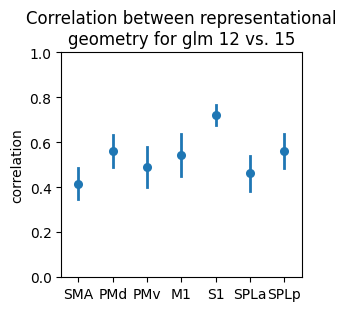

In [17]:
mask = np.tri(5, k=-1, dtype=bool)
corr_dict = {'corr': [], 'roi': [], 'sn': []}
for r, roi in enumerate(rois):
    G12 = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm12.{H}.{roi}.npy'))
    G15 = np.load(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'G_obs.plan.glm15.{H}.{roi}.npy'))
    N = G12.shape[0]
    D = np.r_[pcm.G_to_dist(G12)[:, mask], pcm.G_to_dist(G15)[:, mask]]
    corr = np.diag(np.corrcoef(D)[:N, N:])
    corr_dict['corr'].extend(corr)
    corr_dict['roi'].extend([roi] * corr.size)
    corr_dict['sn'].extend(np.arange(N))

corr_df = pd.DataFrame(corr_dict)

fig, ax = plt.subplots(figsize=(3, 3), constrained_layout=True)
sb.pointplot(ax=ax, data=corr_df, x='roi', y='corr', errorbar='se', lw=2, ls='none',)
ax.set_ylim((0, 1))
ax.set_ylabel('correlation')
ax.set_xlabel(None)
ax.set_title('Correlation between representational\ngeometry for glm 12 vs. 15')
results = corr_df.groupby('roi')['corr'].apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)

T  dof alternative     p-val         CI95%   cohen-d  \
roi  glm                                                                       
M1   12  T-test  2.446785   13     greater  0.014695   [5.97, inf]  0.653931   
     15  T-test  2.501859   13     greater  0.013248   [1.58, inf]  0.668650   
PMd  12  T-test  3.697104   13     greater  0.001342   [5.15, inf]  0.988093   
     15  T-test  1.312948   13     greater  0.105953  [-0.24, inf]  0.350900   
PMv  12  T-test  1.618486   13     greater  0.064776  [-0.12, inf]  0.432559   
     15  T-test -1.162400   13     greater  0.867016  [-0.91, inf]  0.310664   
S1   12  T-test  3.397400   13     greater  0.002383  [34.48, inf]  0.907993   
     15  T-test  2.541088   13     greater  0.012302   [4.67, inf]  0.679134   
SMA  12  T-test  1.081856   13     greater  0.149488  [-0.58, inf]  0.289138   
     15  T-test -0.394794   13     greater  0.650302  [-0.76, inf]  0.105513   
SPLa 12  T-test  3.034924   13     greater  0.004787   [2.44, inf]  0.811117   
     15  T-test  0.831926   13     greater  0.210235  [-0.98, inf]  0.222342   
SPLp 12  T-test  3.251405   13     greater  0.003156   [3.25, inf]  0.868974   
     15  T-test  1.221264   13     greater  0.121836  [-0.74, inf]  0.326396   

                   BF10     power  
roi  glm                           
M1   12  T-test   4.765  0.749094  
     15  T-test   5.172  0.765356  
PMd  12  T-test  33.877  0.967881  
     15  T-test   1.104  0.344489  
PMv  12  T-test    1.55  0.455756  
     15  T-test   0.953  0.002982  
S1   12  T-test  20.947  0.941587  
     15  T-test   5.486  0.776573  
SMA  12  T-test   0.886  0.267945  
     15  T-test   0.578  0.021701  
SPLa 12  T-test  11.768  0.890010  
     15  T-test   0.727  0.196053  
SPLp 12  T-test  16.589  0.923736  
     15  T-test   1.008  0.313116

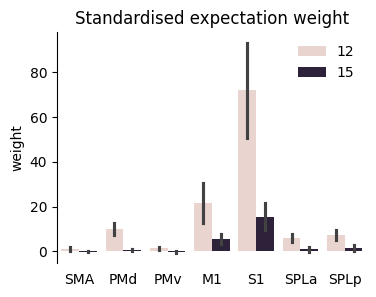

In [6]:
df = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
df['norm_weight'] = np.sqrt(df['weight'] / df['noise'])
comp_model_exp = df[(df.epoch=='plan') & (df.glm.isin([12, 15])) & (df.Hem==H) & (df.label=='none') & (df.component=='expectation')]
comp_model_unc = df[(df.epoch=='plan') & (df.glm.isin([12, 15])) & (df.Hem==H) & (df.label=='none') & (df.component=='uncertainty')]

fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=comp_model_exp, x='roi', y='BF', hue='glm', errorbar='se')
#sb.stripplot(ax=ax, data=df[df.component=='expectation'], x='roi', y='norm_weight', hue='glm', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised expectation weight')
results = comp_model_exp.groupby(['roi', 'glm']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

T  dof alternative     p-val         CI95%   cohen-d  \
roi  glm                                                                       
M1   12  T-test  1.420972   13     greater  0.089433  [-0.47, inf]  0.379771   
     15  T-test  0.232769   13     greater  0.409783  [-0.73, inf]  0.062210   
PMd  12  T-test  2.108148   13     greater  0.027496   [4.07, inf]  0.563426   
     15  T-test  1.762910   13     greater  0.050696  [-0.04, inf]  0.471158   
PMv  12  T-test  2.124096   13     greater  0.026710   [0.56, inf]  0.567689   
     15  T-test  1.129051   13     greater  0.139640  [-0.78, inf]  0.301752   
S1   12  T-test  2.164677   13     greater  0.024804   [0.56, inf]  0.578534   
     15  T-test  1.106618   13     greater  0.144258  [-0.57, inf]  0.295756   
SMA  12  T-test  1.570233   13     greater  0.070186  [-0.31, inf]  0.419662   
     15  T-test  0.105771   13     greater  0.458689  [-1.06, inf]  0.028269   
SPLa 12  T-test  1.675392   13     greater  0.058864  [-0.99, inf]  0.447767   
     15  T-test  1.854193   13     greater  0.043266   [0.17, inf]  0.495554   
SPLp 12  T-test  2.985036   13     greater  0.005269   [6.47, inf]  0.797784   
     15  T-test  1.812229   13     greater  0.046551   [0.09, inf]  0.484339   

                   BF10     power  
roi  glm                           
M1   12  T-test   1.238  0.382850  
     15  T-test   0.553  0.077233  
PMd  12  T-test   2.926  0.637503  
     15  T-test    1.85  0.510156  
PMv  12  T-test   2.992  0.643139  
     15  T-test   0.924  0.282866  
S1   12  T-test   3.167  0.657335  
     15  T-test   0.906  0.275724  
SMA  12  T-test   1.464  0.437710  
     15  T-test   0.543  0.061239  
SPLa 12  T-test    1.66  0.477150  
     15  T-test   2.079  0.544496  
SPLp 12  T-test  10.879  0.880908  
     15  T-test    1.97  0.528736

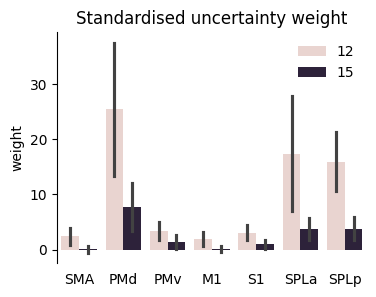

In [7]:
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=comp_model_unc, x='roi', y='BF', hue='glm', errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised uncertainty weight')
results = comp_model_unc.groupby(['roi', 'glm']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

Contrast   A   B  Paired  Parametric         T   dof alternative  \
roi                                                                       
M1   0      glm  12  13    True        True -1.441167  13.0     greater   
     1      glm  12  14    True        True -5.156286  13.0     greater   
     2      glm  12  15    True        True  3.605130  13.0     greater   
     3      glm  13  14    True        True -5.141591  13.0     greater   
     4      glm  13  15    True        True  3.234349  13.0     greater   
     5      glm  14  15    True        True  4.258654  13.0     greater   
PMd  0      glm  12  13    True        True  1.980803  13.0     greater   
     1      glm  12  14    True        True -3.646703  13.0     greater   
     2      glm  12  15    True        True  1.397503  13.0     greater   
     3      glm  13  14    True        True -5.144818  13.0     greater   
     4      glm  13  15    True        True  0.579431  13.0     greater   
     5      glm  14  15    True        True  2.226582  13.0     greater   
PMv  0      glm  12  13    True        True  1.726519  13.0     greater   
     1      glm  12  14    True        True -2.710120  13.0     greater   
     2      glm  12  15    True        True  1.061958  13.0     greater   
     3      glm  13  14    True        True -5.505608  13.0     greater   
     4      glm  13  15    True        True  0.272025  13.0     greater   
     5      glm  14  15    True        True  1.752125  13.0     greater   
S1   0      glm  12  13    True        True -2.045997  13.0     greater   
     1      glm  12  14    True        True -4.871422  13.0     greater   
     2      glm  12  15    True        True  3.590328  13.0     greater   
     3      glm  13  14    True        True -4.595925  13.0     greater   
     4      glm  13  15    True        True  3.345482  13.0     greater   
     5      glm  14  15    True        True  4.045049  13.0     greater   
SMA  0      glm  12  13    True        True  1.183583  13.0     greater   
     1      glm  12  14    True        True -2.253908  13.0     greater   
     2      glm  12  15    True        True  0.236802  13.0     greater   
     3      glm  13  14    True        True -3.740945  13.0     greater   
     4      glm  13  15    True        True -0.302131  13.0     greater   
     5      glm  14  15    True        True  1.103428  13.0     greater   
SPLa 0      glm  12  13    True        True  0.742369  13.0     greater   
     1      glm  12  14    True        True -2.918570  13.0     greater   
     2      glm  12  15    True        True  1.692990  13.0     greater   
     3      glm  13  14    True        True -4.470487  13.0     greater   
     4      glm  13  15    True        True  0.963161  13.0     greater   
     5      glm  14  15    True        True  2.332335  13.0     greater   
SPLp 0      glm  12  13    True        True  1.615611  13.0     greater   
     1      glm  12  14    True        True -2.748020  13.0     greater   
     2      glm  12  15    True        True  0.870466  13.0     greater   
     3      glm  13  14    True        True -3.764124  13.0     greater   
     4      glm  13  15    True        True -0.082725  13.0     greater   
     5      glm  14  15    True        True  1.687177  13.0     greater   

           p-unc    BF10    hedges  
roi                                 
M1   0  0.913406    0.79 -0.173279  
     1  0.999908   0.003 -0.633490  
     2  0.001600  29.226  1.247231  
     3  0.999905   0.003 -0.416703  
     4  0.003261  16.144  1.174531  
     5  0.000466  83.179  1.599346  
PMd  0  0.034587   2.458  0.256391  
     1  0.998522   0.032 -0.507430  
     2  0.092828   1.207  0.381609  
     3  0.999906   0.003 -0.740767  
     4  0.286102   0.625  0.186616  
     5  0.022139   3.457  0.780883  
PMv  0  0.053962   1.768  0.360044  
     1  0.991077   0.141 -0.585088  
     2  0.153793   0.871  0.296757  
     3  0.999949   0.002 -0.933807  
     4  0.394937   0.558  0.092764  
   

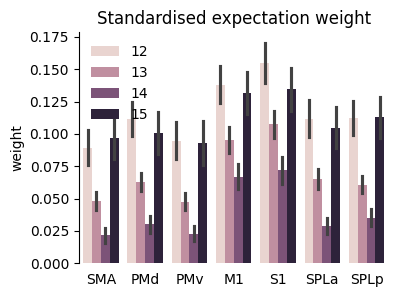

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df[df.component=='expectation'], x='roi', y='norm_weight', hue='glm', errorbar='se')
#sb.stripplot(ax=ax, data=df[df.component=='expectation'], x='roi', y='norm_weight', hue='glm', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised expectation weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='glm', subject='participant_id', alternative='greater'))
display(res)
plt.show()

,,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
roi,,,,,,,,,,,,
M1,0,component,expectation,uncertainty,True,True,3.172144,13.0,greater,0.003676,14.623,1.009846
PMd,0,component,expectation,uncertainty,True,True,-0.925984,13.0,greater,0.814337,0.779,-0.322691
PMv,0,component,expectation,uncertainty,True,True,-0.860484,13.0,greater,0.797444,0.742,-0.325215
S1,0,component,expectation,uncertainty,True,True,4.302647,13.0,greater,0.000430,89.197,1.583621
SMA,0,component,expectation,uncertainty,True,True,-0.205339,13.0,greater,0.579756,0.55,-0.072289
SPLa,0,component,expectation,uncertainty,True,True,-0.736313,13.0,greater,0.762691,0.683,-0.264415
SPLp,0,component,expectation,uncertainty,True,True,-0.936707,13.0,greater,0.817007,0.786,-0.355333


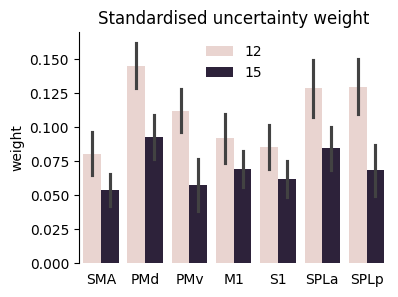

In [9]:
df = pd.read_csv(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, 'component_model.BOLD.tsv'), sep='\t')
df = df[(df.epoch=='plan') & (df.glm.isin([12, 15])) & (df.Hem==H) & (df.label=='none')]
fig, ax = plt.subplots(figsize=(4, 3))
df['norm_weight'] = np.sqrt(df['weight'] / df['noise'])
sb.barplot(ax=ax, data=df[df.component=='uncertainty'], x='roi', y='norm_weight', hue='glm', errorbar='se')
#sb.stripplot(ax=ax, data=df[df.component=='expectation'], x='roi', y='norm_weight', hue='glm', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised uncertainty weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='greater'))
display(res)
plt.show()